In [26]:
import os

if not os.path.exists("pytorch_unet.py"):
  if not os.path.exists("pytorch_unet"):
    !git clone https://github.com/usuyama/pytorch-unet.git

  %cd pytorch-unet

In [27]:
# check torch
import torch

# Device-Konfiguration für Apple Silicon
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using NVIDIA GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Warning: Using CPU, training will be slow!")

print(f"Device: {device}")

Using Apple Silicon GPU (MPS)
Device: mps


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import helper
import simulation

# Generate some random images
input_images, target_masks = simulation.generate_random_data(128, 128, count=64)

print("input_images shape and range", input_images.shape, input_images.min(), input_images.max())
print("target_masks shape and range", target_masks.shape, target_masks.min(), target_masks.max())

# Change channel-order and make 3 channels for matplot
input_images_rgb = [x.astype(np.uint8) for x in input_images]

# Map each channel (i.e. class) to each color
target_masks_rgb = [helper.masks_to_colorimg(x) for x in target_masks]

input_images shape and range (64, 128, 128, 3) 0 255
target_masks shape and range (64, 6, 128, 128) 0.0 1.0


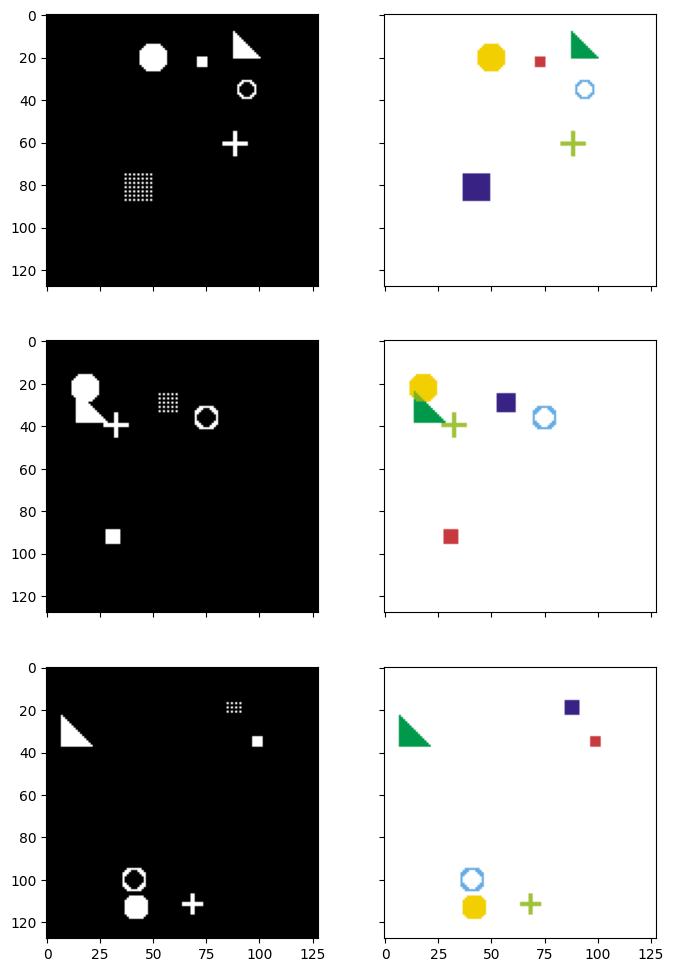

In [29]:
helper.plot_side_by_side([input_images_rgb[:3], target_masks_rgb[:3]])

In [30]:
# prepare data
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets

class SimDataset(Dataset):
  def __init__(self, count, transform=None):
    self.input_images, self.target_masks = simulation.generate_random_data(128, 128, count=count)
    self.transform = transform

  def __len__(self):
    return len(self.input_images)

  def __getitem__(self, idx):
    image = self.input_images[idx]
    mask = self.target_masks[idx]
    if self.transform:
      image = self.transform(image)

    return [image, mask]

# use the same transformations for train/val in this example
trans = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize([0.4, 0.5, 0.6], [0.20, 0.21, 0.22]) # skew channels of binary images
])

train_set = SimDataset(2000, transform = trans)
val_set = SimDataset(200, transform = trans)

image_datasets = {
  'train': train_set, 'val': val_set
}

batch_size = 25

dataloaders = {
  'train': DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0),
  'val': DataLoader(val_set, batch_size=batch_size, shuffle=True, num_workers=0)
}

torch.Size([25, 3, 128, 128]) torch.Size([25, 6, 128, 128])


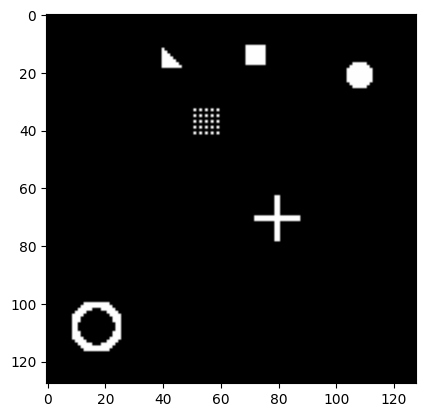

In [31]:
import torchvision.utils

def reverse_transform(inp):
  inp = inp.numpy().transpose((1, 2, 0))
  mean = np.array([0.4, 0.5, 0.6])
  std = np.array([0.20, 0.21, 0.22])
  inp = std * inp + mean
  inp = np.clip(inp, 0, 1)
  inp = (inp * 255).astype(np.uint8)

  return inp

# Get a batch of training data
inputs, masks = next(iter(dataloaders['train']))

print(inputs.shape, masks.shape)

plt.imshow(reverse_transform(inputs[3]))

In [32]:
#define unet
import torch.nn as nn
import torch.nn.functional as F

def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.ReLU(inplace=True)
    )


class UNet(nn.Module):

    def __init__(self, n_class):
        super().__init__()

        # Encoder (Downsampling)
        self.dconv_down1 = double_conv(3, 64)
        self.dconv_down2 = double_conv(64, 128)
        self.dconv_down3 = double_conv(128, 256)
        self.dconv_down4 = double_conv(256, 512)

        self.maxpool = nn.MaxPool2d(2)
        
        # ÄNDERUNG: ConvTranspose2d statt nn.Upsample
        # kernel_size=2, stride=2 verdoppelt die räumliche Auflösung
        self.upsample3 = nn.ConvTranspose2d(512, 512, kernel_size=2, stride=2)
        self.upsample2 = nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2)
        self.upsample1 = nn.ConvTranspose2d(128, 128, kernel_size=2, stride=2)

        # Decoder (Upsampling)
        self.dconv_up3 = double_conv(256 + 512, 256)
        self.dconv_up2 = double_conv(128 + 256, 128)
        self.dconv_up1 = double_conv(128 + 64, 64)

        self.conv_last = nn.Conv2d(64, n_class, 1)


    def forward(self, x):
        # Encoder
        conv1 = self.dconv_down1(x)     # 64 channels
        x = self.maxpool(conv1)

        conv2 = self.dconv_down2(x)     # 128 channels
        x = self.maxpool(conv2)

        conv3 = self.dconv_down3(x)     # 256 channels
        x = self.maxpool(conv3)

        x = self.dconv_down4(x)         # 512 channels (Bottleneck)

        # Decoder mit ConvTranspose2d
        x = self.upsample3(x)           # 512 channels, Größe verdoppelt
        x = torch.cat([x, conv3], dim=1)  # 512 + 256 = 768 channels
        x = self.dconv_up3(x)           # -> 256 channels

        x = self.upsample2(x)           # 256 channels, Größe verdoppelt
        x = torch.cat([x, conv2], dim=1)  # 256 + 128 = 384 channels
        x = self.dconv_up2(x)           # -> 128 channels

        x = self.upsample1(x)           # 128 channels, Größe verdoppelt
        x = torch.cat([x, conv1], dim=1)  # 128 + 64 = 192 channels
        x = self.dconv_up1(x)           # -> 64 channels

        out = self.conv_last(x)         # -> n_class channels

        return out


model = UNet(6).to(device)  # Statt .cuda()

In [33]:
#from torchsummary import summary
#summary(model, input_size=(3, 128, 128), device='mps')

from torchinfo import summary
summary(model, input_size=(1, 3, 128, 128), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 6, 128, 128]          --
├─Sequential: 1-1                        [1, 64, 128, 128]         --
│    └─Conv2d: 2-1                       [1, 64, 128, 128]         1,792
│    └─ReLU: 2-2                         [1, 64, 128, 128]         --
│    └─Conv2d: 2-3                       [1, 64, 128, 128]         36,928
│    └─ReLU: 2-4                         [1, 64, 128, 128]         --
├─MaxPool2d: 1-2                         [1, 64, 64, 64]           --
├─Sequential: 1-3                        [1, 128, 64, 64]          --
│    └─Conv2d: 2-5                       [1, 128, 64, 64]          73,856
│    └─ReLU: 2-6                         [1, 128, 64, 64]          --
│    └─Conv2d: 2-7                       [1, 128, 64, 64]          147,584
│    └─ReLU: 2-8                         [1, 128, 64, 64]          --
├─MaxPool2d: 1-4                         [1, 128, 32, 32]          --

In [34]:
import time
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 15

for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs - 1))
    print('-' * 10)

    since = time.time()

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        epoch_samples = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)   # Statt .cuda()
            labels = labels.to(device)   # Statt .cuda()

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss = F.binary_cross_entropy_with_logits(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            epoch_samples += inputs.size(0)

        print(f"{(loss.detach().cpu().numpy(), epoch_samples, phase)}")

    time_elapsed = time.time() - since
    print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

Epoch 0/14
----------
(array(0.02090978, dtype=float32), 2000, 'train')
(array(0.01999138, dtype=float32), 200, 'val')
0m 30s
Epoch 1/14
----------
(array(0.01268237, dtype=float32), 2000, 'train')
(array(0.01180776, dtype=float32), 200, 'val')
0m 29s
Epoch 2/14
----------
(array(0.0092009, dtype=float32), 2000, 'train')
(array(0.00867417, dtype=float32), 200, 'val')
0m 29s
Epoch 3/14
----------
(array(0.00660908, dtype=float32), 2000, 'train')
(array(0.00664813, dtype=float32), 200, 'val')
0m 29s
Epoch 4/14
----------
(array(0.00521952, dtype=float32), 2000, 'train')
(array(0.00510373, dtype=float32), 200, 'val')
0m 29s
Epoch 5/14
----------
(array(0.00439619, dtype=float32), 2000, 'train')
(array(0.00461437, dtype=float32), 200, 'val')
0m 30s
Epoch 6/14
----------
(array(0.00313242, dtype=float32), 2000, 'train')
(array(0.00377908, dtype=float32), 200, 'val')
0m 29s
Epoch 7/14
----------
(array(0.00253728, dtype=float32), 2000, 'train')
(array(0.00257488, dtype=float32), 200, 'val')


inputs.shape torch.Size([3, 3, 128, 128])
labels.shape torch.Size([3, 6, 128, 128])
pred.shape (3, 6, 128, 128)


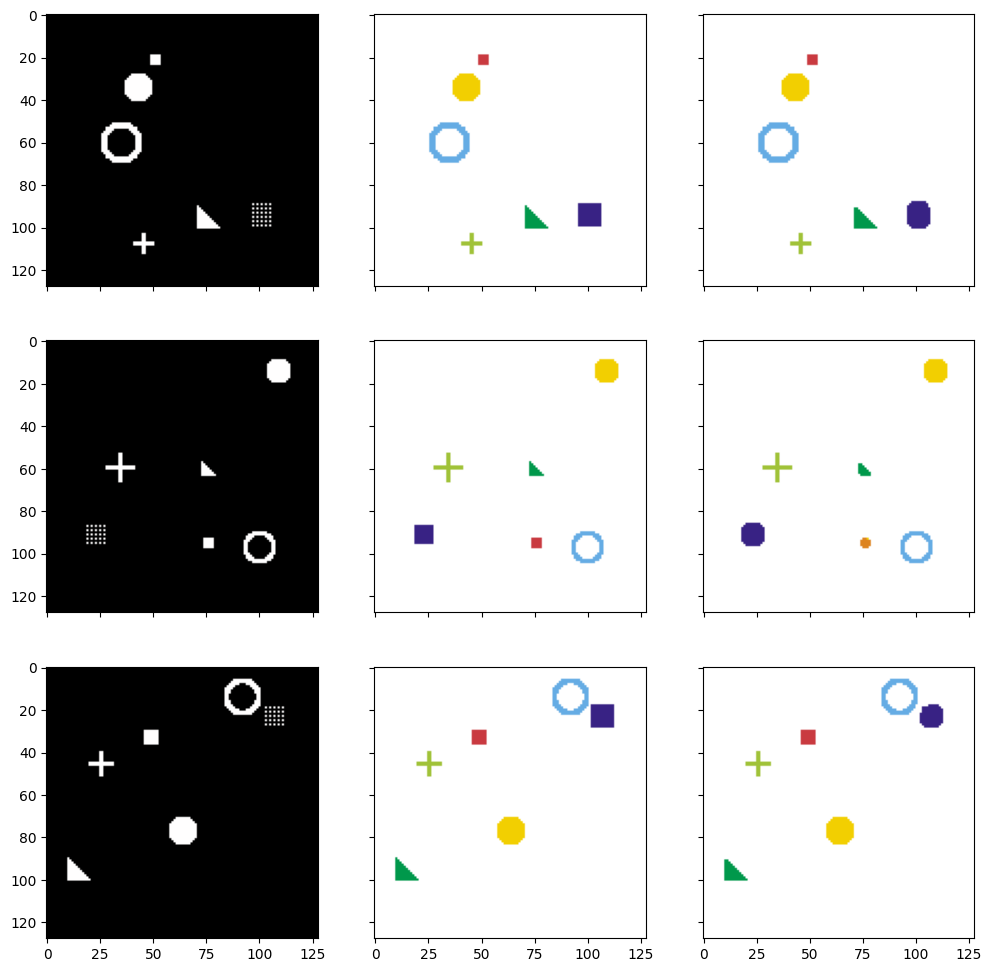

In [35]:
import math

model.eval()

test_dataset = SimDataset(3, transform=trans)
test_loader = DataLoader(test_dataset, batch_size=3, shuffle=False, num_workers=0)

inputs, labels = next(iter(test_loader))
inputs = inputs.to(device)   # Statt .cuda()
labels = labels.to(device)   # Statt .cuda()

print('inputs.shape', inputs.shape)
print('labels.shape', labels.shape)

# Predict
pred = model(inputs)
pred = torch.sigmoid(pred)
pred = pred.data.cpu().numpy()
print('pred.shape', pred.shape)

# Visualization
input_images_rgb = [reverse_transform(x) for x in inputs.cpu()]
target_masks_rgb = [helper.masks_to_colorimg(x) for x in labels.cpu().numpy()]
pred_rgb = [helper.masks_to_colorimg(x) for x in pred]

helper.plot_side_by_side([input_images_rgb, target_masks_rgb, pred_rgb])

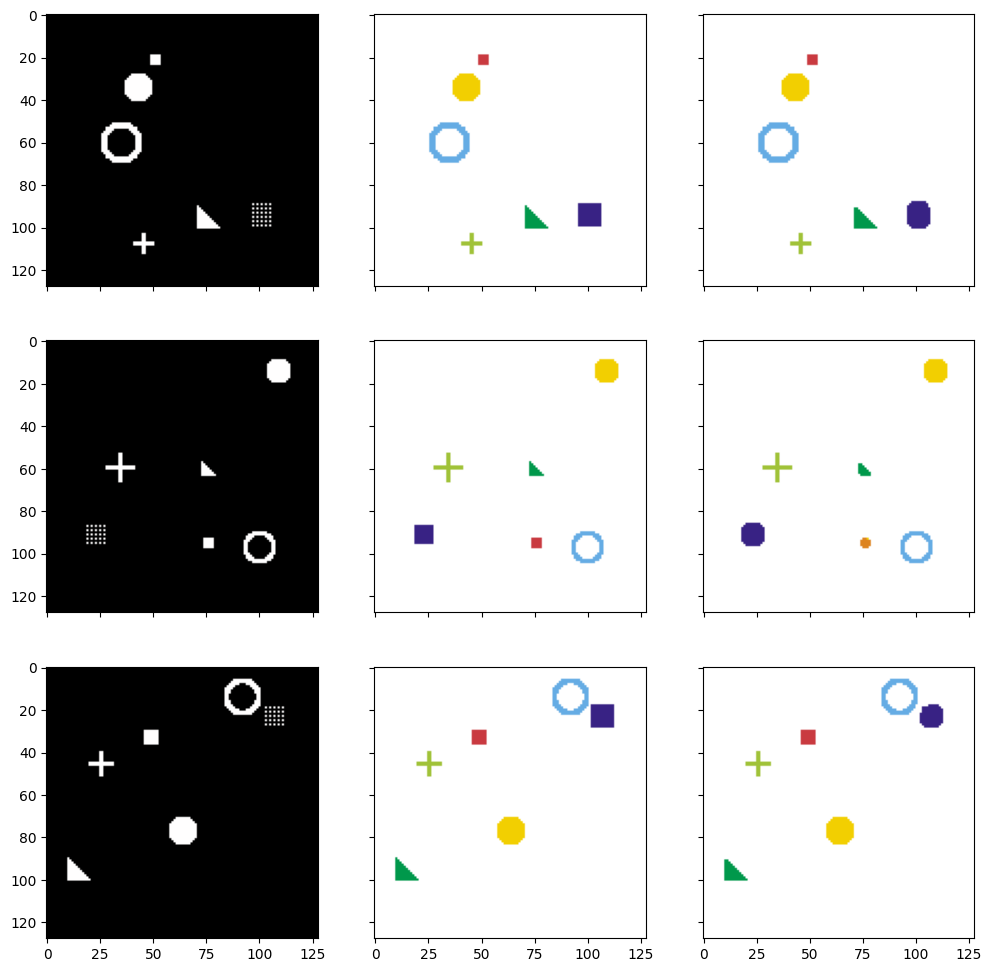

In [36]:
helper.plot_side_by_side([input_images_rgb, target_masks_rgb, pred_rgb])